# Computer Vision Homework 01 - Panoramas, Image Features, and Calibration

Contact: David C. Schedl (david.schedl@fh-hagenberg.at)

Note: this is the starter pack for the **Visual Computing** homework. You do not need to use this template!

## Task:
This exercise features a variety of tasks, ideas and algorithms we covered previously. The goal is to get familiar with the concepts and to apply them to a real-world problem.
Therefore, for this exercise you get uncalibrated image pairs of thermal and RGB images of multiple scenes recorded with one of our BAMBI drones. 

Based on the images you should try to solve (some of) the following tasks and answer the following questions:
* **Panorama stitching:** Create a panorama image from the RGB images. You can use the `ellipse` or `FH3` scenes for this task. Can you compute a panorama from the thermal images? 
* **Image features (thermal to RGB):** Detect and match image features from the thermal to the RGB images. How many features do you find? Which feature descriptors are suitable for this task? Which scenes work and which don't? How can you measure the quality of the matches?
* **Camera Calibration:** Calibrate the camera with the thermal and/or RGB images. How many images do you need? Does it work at all? How well does the calibration work? How can you measure the quality of the calibration?
* **Extrinsic Estimation:** Try to estimate the rotation and translation of the drone. How well does it work? How can you measure the quality of the estimation? 

Note that the cameras are mounted on a gimbal and therefore the cameras are perfectly aligned (no rotation and assume no translation between the thermal and RGB camera).
The RGB camera has a larger field of view than the thermal camera. 

Use feature descriptors to find correspondences and match them. Matching can be done with the nearest neighbour distance or any other strategy. 
To estimate the extrinsic parameters, you can use OpenCV's [`findEssentialMat`](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#gad245d60e64d0c1270dbfd0520847bb87), [`findFundamentalMat`](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#gad245d60e64d0c1270dbfd0520847bb87), or any similar function. 


**Further comments/hints:**

*   The thermal camera has severe distortions. Don't worry too much about imprecisions. 
*   If you have troubles with the intrinsic calibration I provide a ground truth calibration for both cameras below. However, try to it without the ground truth first.
*   Think about the problem 🤔, solve it, and critically evaluate your solution.
*   You can downscale the RGB images to speed up the computation.
*   Summarize your ideas and findings in the report. 



**Have fun!** 😸


## Initialization and Download

Let's import useful libraries, first. 
Then download some scenes with `curl`.

**Scenes:**

You can use the following scenes `ellipse`, `FH3`, `forest`, `hut`. 
They are located in the `data` folder after download and are well suited for various tasks:
* `ellipse` scene showing the FH's ellipse. Drone was hovering and only rotating around the up-axis. Perfect for panorama stitching.
* `FH3`  scene showing the FH's FH3 building. Drone was flying at a horizontal distance of around 60m to the building. Suitable for panorama stitching.
* `forest` scene showing a forest. Drone was flying 50m above the ground. There is no overlap between the images, so panorama stitching is not possible.
* `hut` scene showing a hut in a zoo. Drone was flying in circular movements around the front of the hut. Might be suitable for panorama stitching (but will be hard).


Furthermore, let's define utility functions to display images, in Jupyter Notebooks. OpenCV's `imshow` does not work and matplotlib's `imshow` needs special treatment due to color channel handling (RGB vs. BGR)

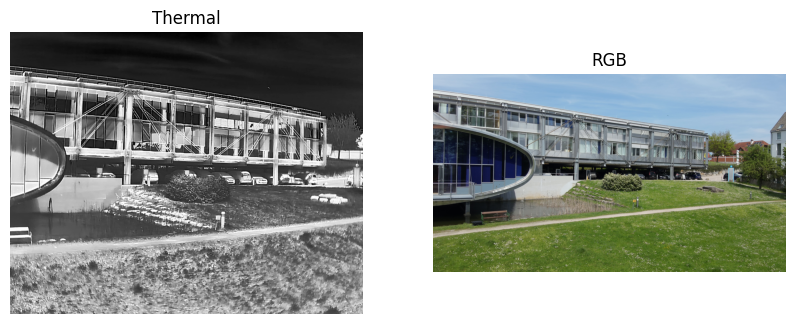

In [2]:
# import the libraries we use
import os
import cv2  # openCV
import numpy as np
import matplotlib.pyplot as plt
import glob  # library for loading images from a directory


def download_cv_dataset(dataset: str, extract_to: str = "./data"):
    # change the current working directory
    old_working_dir = os.getcwd()
    if not os.path.exists(extract_to):
        os.mkdir(extract_to)
    os.chdir(extract_to)
    try:
        # check if the file exists
        if not os.path.exists(os.path.join(extract_to, dataset)):
            !curl -LJO "https://raw.githubusercontent.com/Digital-Media/cv_data/main/{dataset}" --silent
        import zipfile

        with zipfile.ZipFile(dataset, "r") as zip_ref:
            zip_ref.extractall(".")
    except Exception as e:
        print(f"Error: Please check if the dataset {dataset} exists.")
        # print the error message
        print(e)
    finally:
        # change back to the original working directory
        os.chdir(old_working_dir)


# utility function(s)
def imshow(image, *args, **kwargs):
    """A replacement for cv2.imshow() for use in Jupyter notebooks using matplotlib.

    Args:
      image : np.ndarray. shape (N, M) or (N, M, 1) is an NxM grayscale image. shape
        (N, M, 3) is an NxM BGR color image.
    """
    if len(image.shape) == 3:
        # Height, width, channels
        # Assume BGR, do a conversion
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw the image
    plt.imshow(image, *args, **kwargs)
    # We'll also disable drawing the axes and tick marks in the plot, since it's actually an image
    plt.axis("off")
    # Make sure it outputs
    # plt.show()


# read the images from the dataset folder
def read_images(dataset: str):
    # get the list of images from the dataset folder
    T_img_files = sorted(glob.glob(f"./data/{dataset}/T_*.png"))
    W_img_files = sorted(glob.glob(f"./data/{dataset}/W_*.png"))
    # assert that the number of images is the same
    assert len(T_img_files) == len(W_img_files)

    # if there are no images, raise an error
    if len(T_img_files) == 0:
        raise ValueError(f"No images found in the {dataset} folder.")

    T_imgs = []
    W_imgs = []

    for i in range(len(T_img_files)):
        # read the images
        T_img = cv2.imread(T_img_files[i])
        W_img = cv2.imread(W_img_files[i])
        # add the images to a list
        W_imgs.append(W_img)
        T_imgs.append(T_img)

    return {"Thermal": T_imgs, "RGB": W_imgs}


download_cv_dataset(
    "thermal-rgb_ellipse.zip"
)  # <-- scene showing the FH's ellipse. Drone was hovering and only rotating around the up-axis. Perfect for panorama stitching.
download_cv_dataset(
    "thermal-rgb_FH3.zip"
)  # <-- scene showing the FH's FH3 building. Drone was flying at a horizontal distance of around 60m to the building. Suitable for panorama stitching.
download_cv_dataset(
    "thermal-rgb_forest.zip"
)  # <-- scene showing a forest. Drone was flying 50m above the ground. There is no overlap between the images, so panorama stitching is not possible.
download_cv_dataset(
    "thermal-rgb_hut.zip"
)  # <-- scene showing a hut in a zoo. Drone was flying in circular movements around the front of the hut. Might be suitable for panorama stitching (but will be hard).


# read the images
# use one of the following datasets: "ellipse", "FH3", "forest", "hut"
images = read_images("ellipse")


plt.figure(figsize=(10, 10))
plt.subplot(121), plt.title("Thermal")
imshow(images["Thermal"][0])
plt.subplot(122), plt.title("RGB")
imshow(images["RGB"][0])

# Ground Truth Intrinsic Calibration
Below you can find the ground truth intrinsic calibration for both cameras. Use it if you have troubles with the intrinsic calibration.
Especially the distortion coefficients might be handy.

In [3]:
gt_calibrations = {
    "Thermal": {
        "K": [
            [1523.7602359891657, 0.0, 618.0480346862191],
            [0.0, 1491.3570424347292, 507.1000881569456],
            [0.0, 0.0, 1.0],
        ],
        "dist": [
            [
                -0.3880250851012345,
                0.3744059275961452,
                0.0010497689153120373,
                0.00011610446402566044,
                0.0,
            ]
        ],
    },
    "RGB": {
        "K": [
            [2888.178324915765, 0.0, 1929.0179499431672],
            [0.0, 2819.3160759551897, 1070.7804294784548],
            [0.0, 0.0, 1.0],
        ],
        "dist": [
            [
                0.13853585738444427,
                -0.25508562557544706,
                0.00020336601637138113,
                -0.0009057472383396885,
                0.0,
            ]
        ],
    },
}

### Overlaying RGB and Thermal Images

Once you have the intrinsic calibrations, you can overlay the RGB and thermal images.

<Figure size 2000x800 with 0 Axes>

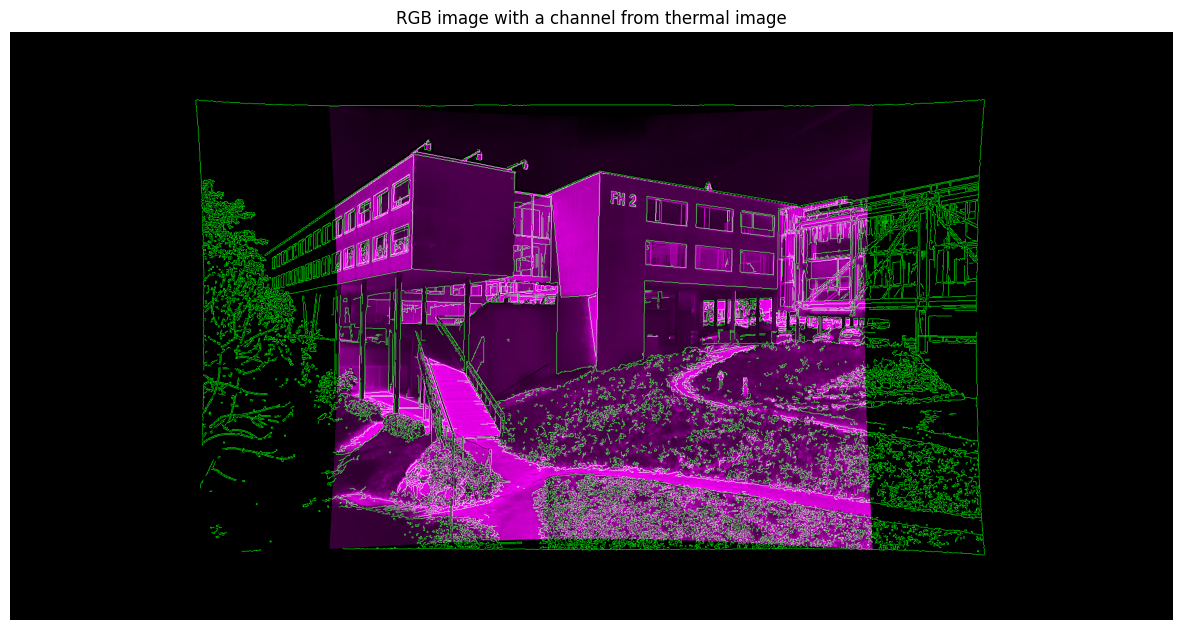

In [4]:
# hard coded camera matrix for undistortion
dst_size = (2024, 1024)
f = min(*dst_size)
new_camera_matrix = np.array(
    [[f, 0.0, dst_size[0] / 2 - 0.5], [0.0, f, dst_size[1] / 2 - 0.5], [0.0, 0.0, 1.0]]
)


def overlay_images(
    images, calibrations, selected_img_id=0, show_individual_images=False
):
    plt.figure(figsize=(20, 8))
    for i, camera in enumerate(images.keys()):
        # calib = saver.get(get_resource("calibration.db"), drone_name, camera, normalize_calibration=True)
        calib = calibrations.get(camera)
        assert calib is not None

        camera_matrix = np.array(calib["K"])
        # k1, k2, p1, p2, k3
        dist_coefs = np.array(calib["dist"])

        if selected_img_id >= len(images[camera]):
            print("WARNING: selected_img_id is out of range.")
            selected_img_id = len(images[camera]) - 1

        img = images[camera][selected_img_id]

        # remove the the lens distortions
        mapx, mapy = cv2.initUndistortRectifyMap(
            camera_matrix, dist_coefs, None, new_camera_matrix, dst_size, cv2.CV_32FC1
        )
        dst = cv2.remap(img, mapx, mapy, cv2.INTER_CUBIC)
        # print(dst_T.shape)

        if show_individual_images:
            plt.subplot(1, len(calibrations), i + 1)
            imshow(dst, cmap="gray")
            plt.title(f"undistorted {camera} image")

        if camera == "RGB":
            # apply an edge detector on the wide image
            dst = cv2.Canny(dst.copy(), 100, 200)
            rgb_img_edge = cv2.cvtColor(dst, cv2.COLOR_GRAY2RGB)
        else:
            thermal_img = dst.copy()
            cmp_img = thermal_img.copy()
    plt.show()  # show the images

    cmp_img[:, :, 1] = rgb_img_edge[:, :, 1]  # copy a channel from the thermal image

    plt.figure(figsize=(15, 8))
    imshow(cmp_img, cmap="gray")
    plt.title(f"RGB image with a channel from thermal image")
    plt.show()


overlay_images(images, gt_calibrations, 6)

# Homework solution
## Panorama stitching
* Create a panorama image from the RGB images. You can use the `ellipse` or `FH3` scenes for this task. Can you compute a panorama from the thermal images?
### RGB

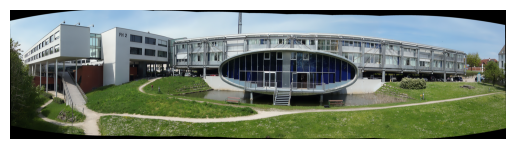

In [16]:
stitcher = cv2.Stitcher_create()
_, panorama = stitcher.stitch(images["RGB"])

imshow(panorama)

### Thermal

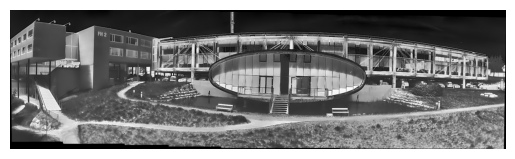

In [14]:
#stitcher = cv2.Stitcher_create()
_, panorama = stitcher.stitch(images["Thermal"])

imshow(panorama)

Yes, I can stitch thermal images together!

## Image features
* Detect and match image features from the thermal to the RGB images. How many features do you find? Which feature descriptors are suitable for this task? Which scenes work and which don't? How can you measure the quality of the matches?

In [7]:
def evaluate_descriptor(detector, norm_type, scene_name, image_idx=0):
    """
    Detect and match features between one thermal and RGB image.
    """

    images = read_images(scene_name)

    thermal = cv2.cvtColor(images["Thermal"][image_idx], cv2.COLOR_BGR2GRAY)
    rgb = cv2.cvtColor(images["RGB"][image_idx], cv2.COLOR_BGR2GRAY)

    kp_t, des_t = detector.detectAndCompute(thermal, None)
    kp_r, des_r = detector.detectAndCompute(rgb, None)

    if des_t is None or des_r is None:
        return None

    bf = cv2.BFMatcher(norm_type)

    matches = bf.knnMatch(des_t, des_r, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    matched_img = cv2.drawMatches(
        thermal,
        kp_t,
        rgb,
        kp_r,
        good,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    return {
        "scene": scene_name,
        "keypoints_thermal": len(kp_t),
        "keypoints_rgb": len(kp_r),
        "good_matches": len(good),
        "image": matched_img,
    }



In [8]:
descriptors = {
    "SIFT": (cv2.SIFT_create(), cv2.NORM_L2),
    "ORB": (cv2.ORB_create(20000), cv2.NORM_HAMMING),
    "AKAZE": (cv2.AKAZE_create(), cv2.NORM_HAMMING),
}

scenes = ["ellipse", "FH3", "forest", "hut"]

results = []

for descriptor_name, (detector, norm) in descriptors.items():

    for scene in scenes:

        result = evaluate_descriptor(detector, norm, scene)

        if result is None:
            print(scene, "-> failed")
            continue

        result["descriptor"] = descriptor_name
        results.append(result)

In [9]:
import pandas as pd

df = pd.DataFrame(results)

display(
    df[
        [
            "descriptor",
            "scene",
            "keypoints_thermal",
            "keypoints_rgb",
            "good_matches",
        ]
    ]
)

,descriptor,scene,keypoints_thermal,keypoints_rgb,good_matches
0,SIFT,ellipse,18860,60270,74
1,SIFT,FH3,2656,19126,40
2,SIFT,forest,3368,26255,15
3,SIFT,hut,11806,120369,36
4,ORB,ellipse,20000,20000,88
5,ORB,FH3,8987,20000,45
6,ORB,forest,7694,19441,60
7,ORB,hut,19189,20000,41
8,AKAZE,ellipse,10521,21427,43
9,AKAZE,FH3,1455,10028,8


ORB and SIFT produced the most useful results. ORB generated the highest number of good matches after increasing the maximum number of detected features, while SIFT provided stable results with fewer features. AKAZE produced fewer correspondences in all scenes. The quality of the matches should not only be evaluated by the number of matches, but also by the ratio of good matches and by geometric verification using RANSAC inliers.

## Camera Calibration
* Calibrate the camera with the thermal and/or RGB images. How many images do you need? Does it work at all? How well does the calibration work? How can you measure the quality of the calibration?

In [10]:
calibration_images = sorted(glob.glob("./data/*.jpg"))

def calibrate(images, chessboard_size=(9, 6)):
    object_points = []
    image_points = []

    objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)

    for filename in images:
        img = cv2.imread(filename)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        found, corners = cv2.findChessboardCorners(gray, chessboard_size)

        if found:
            corners = cv2.cornerSubPix(
                gray,
                corners,
                (11, 11),
                (-1, -1),
                (
                    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
                    30,
                    0.001,
                ),
            )

            object_points.append(objp)
            image_points.append(corners)

    error, K, dist, rvecs, tvecs = cv2.calibrateCamera(
        object_points,
        image_points,
        gray.shape[::-1],
        None,
        None,
    )

    return error, K, dist, rvecs, tvecs

In [11]:
for i in range(2, len(calibration_images) // 2 + 1):
    error, _, _, _, _ = calibrate(calibration_images[:i])
    print(f"Reprojection error with {i} images: {error:.4f} pixels")

Reprojection error with 2 images: 0.8000 pixels
Reprojection error with 3 images: 0.6925 pixels
Reprojection error with 4 images: 0.6132 pixels
Reprojection error with 5 images: 0.5578 pixels
Reprojection error with 6 images: 0.5189 pixels
Reprojection error with 7 images: 0.4905 pixels
Reprojection error with 8 images: 0.4682 pixels
Reprojection error with 9 images: 0.4527 pixels
Reprojection error with 10 images: 0.4527 pixels
Reprojection error with 11 images: 0.4336 pixels
Reprojection error with 12 images: 0.4183 pixels
Reprojection error with 13 images: 0.4223 pixels
Reprojection error with 14 images: 0.4087 pixels


Camera calibration was performed using the provided chessboard images, as the thermal and RGB scene images are not suitable for intrinsic calibration. A minimum of 3 images is required for calibration. Increasing the number of images improves the accuracy, reducing the reprojection error from 0.6925 pixels to 0.4087 pixels. Calibration quality is commonly measured by the reprojection error, where lower values indicate a more accurate camera model.

## Extrinsic Estimation
* Try to estimate the rotation and translation of the drone. How well does it work? How can you measure the quality of the estimation? 

In [12]:
img1 = images["RGB"][0]
img2 = images["RGB"][1]

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

matcher = cv2.BFMatcher()
matches = matcher.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])


K = np.array(gt_calibrations["RGB"]["K"])

E, mask = cv2.findEssentialMat(
    pts1,
    pts2,
    K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0
)

_, R, t, mask_pose = cv2.recoverPose(
    E,
    pts1,
    pts2,
    K
)

print("Rotation matrix:")
print(R)

print("Translation direction:")
print(t)

Rotation matrix:
[[ 0.90984978 -0.00178739  0.41493395]
 [-0.00111064  0.99997665  0.00674292]
 [-0.41493632 -0.00659588  0.90982655]]
Translation direction:
[[-0.98401138]
 [-0.04611656]
 [ 0.17203161]]


The camera motion was estimated using feature correspondences, the essential matrix, and pose recovery. The method successfully estimated the relative rotation and translation direction between two images. The quality of the estimation depends on the number and accuracy of feature matches and can be measured using the number of RANSAC inliers or by comparing the estimated motion with ground truth data.